Starting Training...
Epoch [10/50], Loss: 0.0607
Epoch [20/50], Loss: 0.0100
Epoch [30/50], Loss: 0.0025
Epoch [40/50], Loss: 0.0006
Epoch [50/50], Loss: 0.0004


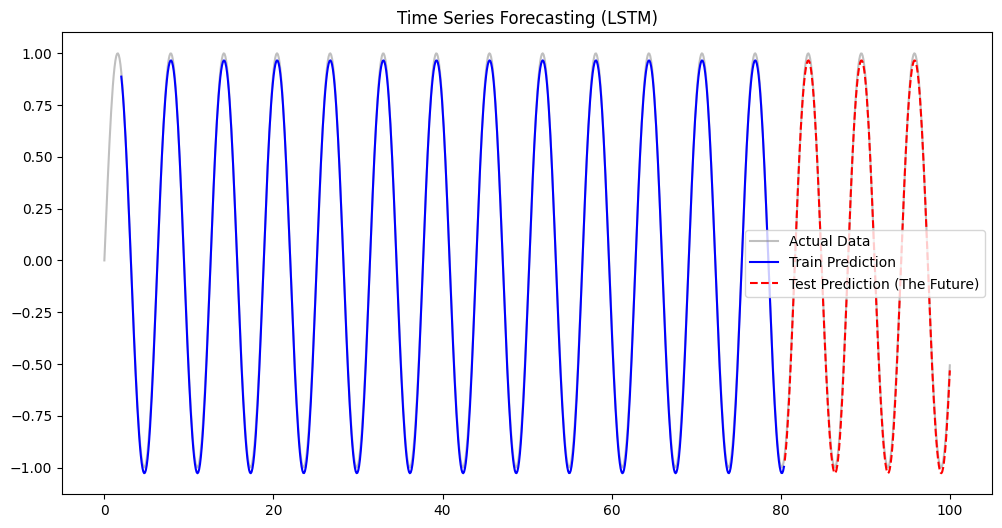

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


t = np.linspace(0, 100, 1000)
data = np.sin(t)

# Input:  [Day 1, Day 2, ... Day 10]
# Output: [Day 11]

def create_sequences(data, window_size):
    inputs, targets = [], []
    for i in range(len(data) - window_size):
        # Take 10 steps as input
        inputs.append(data[i:i+window_size])
        # Take the next step as the target
        targets.append(data[i+window_size])
    return np.array(inputs), np.array(targets)

WINDOW_SIZE = 20
X, y = create_sequences(data, WINDOW_SIZE)

# LSTM expects input shape: (Batch Size, Sequence Length, Input Features)
#  (980 samples, 20 time steps, 1 feature)
X_tensor = torch.FloatTensor(X).unsqueeze(2)
y_tensor = torch.FloatTensor(y).unsqueeze(1)


train_size = int(len(X_tensor) * 0.8)
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

class TimeSeriesLSTM(nn.Module):
    def __init__(self):
        super(TimeSeriesLSTM, self).__init__()
        # LSTM Layer: Input size 1, Hidden size 50
        self.lstm = nn.LSTM(input_size=1, hidden_size=50, batch_first=True)
        # Fully Connected Layer: Maps the 50 hidden features to 1 output value
        self.fc = nn.Linear(50, 1)

    def forward(self, x):
        # LSTM outputs: (out, (hidden_state, cell_state))
        # We only care about the output of the LAST time step
        out, _ = self.lstm(x)
        last_time_step = out[:, -1, :]
        prediction = self.fc(last_time_step)
        return prediction

model = TimeSeriesLSTM()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


print("Starting Training...")
for epoch in range(50):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/50], Loss: {loss.item():.4f}")


model.eval()
with torch.no_grad():
    train_pred = model(X_train).numpy()
    test_pred = model(X_test).numpy()


plt.figure(figsize=(12, 6))
# original data
plt.plot(t, data, label='Actual Data', alpha=0.5, color='gray')
# training predictions
plt.plot(t[WINDOW_SIZE:train_size+WINDOW_SIZE], train_pred, label='Train Prediction', color='blue')
# test predictions (The "Future")
plt.plot(t[train_size+WINDOW_SIZE:], test_pred, label='Test Prediction (The Future)', color='red', linestyle='--')

plt.title('Time Series Forecasting (LSTM)')
plt.legend()
plt.show()

Training on Noisy Data...
Epoch [20/100], Loss: 0.0301
Epoch [40/100], Loss: 0.0196
Epoch [60/100], Loss: 0.0179
Epoch [80/100], Loss: 0.0163
Epoch [100/100], Loss: 0.0149


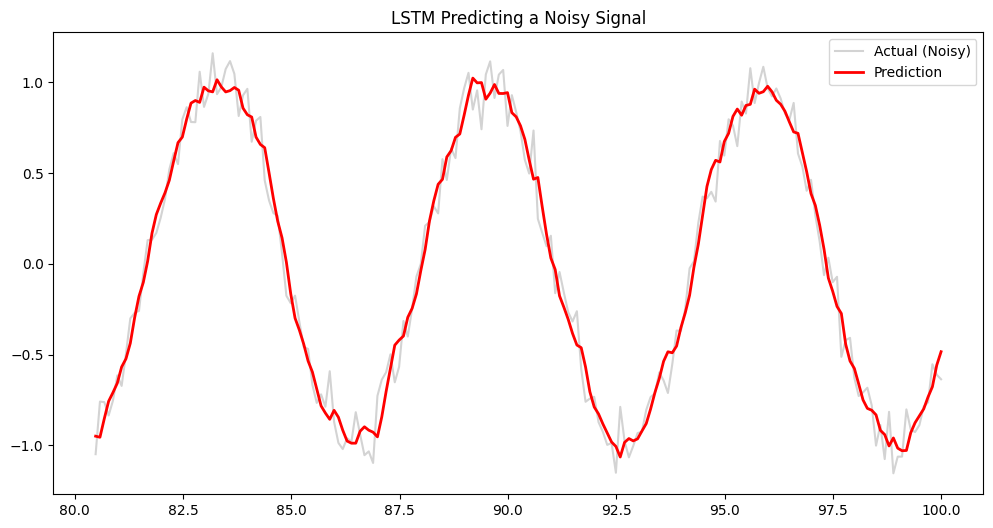

In [2]:

noisy_data = np.sin(t) + np.random.normal(0, 0.1, 1000)

# Create sequences again with the NOISY data
X_noisy, y_noisy = create_sequences(noisy_data, WINDOW_SIZE)

# Convert to Tensors
X_tensor_n = torch.FloatTensor(X_noisy).unsqueeze(2)
y_tensor_n = torch.FloatTensor(y_noisy).unsqueeze(1)

# Split
train_size = int(len(X_tensor_n) * 0.8)
X_train_n, X_test_n = X_tensor_n[:train_size], X_tensor_n[train_size:]
y_train_n, y_test_n = y_tensor_n[:train_size], y_tensor_n[train_size:]


model_noisy = TimeSeriesLSTM()
optimizer = optim.Adam(model_noisy.parameters(), lr=0.01)

print("Training on Noisy Data...")
for epoch in range(100): # Need more epochs for messy data
    model_noisy.train()
    outputs = model_noisy(X_train_n)
    loss = criterion(outputs, y_train_n)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")


model_noisy.eval()
with torch.no_grad():
    test_pred_n = model_noisy(X_test_n).numpy()

plt.figure(figsize=(12, 6))
# messy data (Grey)
plt.plot(t[train_size+WINDOW_SIZE:], y_test_n.numpy(), label='Actual (Noisy)', color='lightgray')
# prediction (Red)
plt.plot(t[train_size+WINDOW_SIZE:], test_pred_n, label='Prediction', color='red', linewidth=2)
plt.title('LSTM Predicting a Noisy Signal')
plt.legend()
plt.show()